In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [15]:
df = pd.read_csv(
    "../data/processed/upi_transactions_processed.csv",
    parse_dates=["timestamp"]
)

In [16]:
print("=" * 60)
print("UPI TRANSACTION INTELLIGENCE PLATFORM")
print("Exploratory Data Analysis")
print("=" * 60)

print(f"Rows               : {df.shape[0]:,}")
print(f"Columns            : {df.shape[1]}")
print(f"Missing Values     : {df.isnull().sum().sum()}")
print(f"Duplicate Records  : {df.duplicated().sum()}")

UPI TRANSACTION INTELLIGENCE PLATFORM
Exploratory Data Analysis
Rows               : 250,000
Columns            : 17
Missing Values     : 0
Duplicate Records  : 0


In [17]:
df.dtypes

transaction_id                object
timestamp             datetime64[ns]
transaction_type              object
merchant_category             object
amount_inr                     int64
transaction_status            object
sender_age_group              object
receiver_age_group            object
sender_state                  object
sender_bank                   object
receiver_bank                 object
device_type                   object
network_type                  object
fraud_flag                     int64
hour_of_day                    int64
day_of_week                   object
is_weekend                     int64
dtype: object

In [18]:
df.head()

,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [20]:
## 6.2.1 Transaction Type Distribution

### Business Question
# Which transaction type is most frequently used in the dataset?

### Objective
# To analyze the frequency and percentage distribution of UPI transaction types.

In [ ]:
## Frequency Distribution of Transaction Types
transaction_type = (
    df["transaction_type"]
      .value_counts()
      .reset_index()
)

transaction_type.columns = [
    "Transaction Type",
    "Transaction Count"
]

transaction_type

,Transaction Type,Transaction Count
0,P2P,112445
1,P2M,87660
2,Bill Payment,37368
3,Recharge,12527


In [ ]:
## Percentage Distribution of Transaction Types
transaction_type["Percentage"] = (
    transaction_type["Transaction Count"]
    / transaction_type["Transaction Count"].sum()
    * 100
).round(2)

transaction_type

,Transaction Type,Transaction Count,Percentage
0,P2P,112445,44.98
1,P2M,87660,35.06
2,Bill Payment,37368,14.95
3,Recharge,12527,5.01


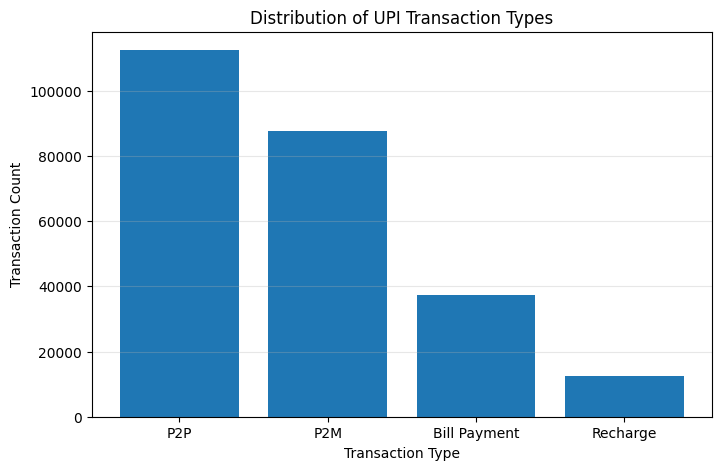

In [ ]:
## Bar Chart Visualization 
plt.figure(figsize=(8,5))

plt.bar(
    transaction_type["Transaction Type"],
    transaction_type["Transaction Count"]
)

plt.title("Distribution of UPI Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Count")

plt.grid(axis="y", alpha=0.3)

plt.show()

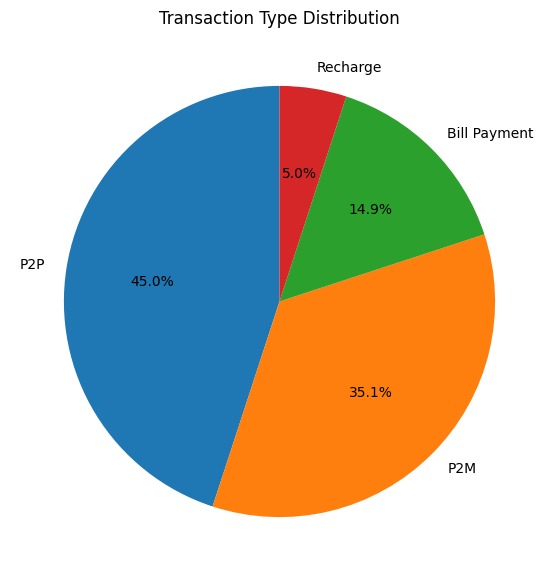

In [ ]:
## Pie Chart Visualization
plt.figure(figsize=(7,7))

plt.pie(
    transaction_type["Transaction Count"],
    labels=transaction_type["Transaction Type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Transaction Type Distribution")

plt.show()

In [ ]:
## Most Frequently Used Transaction Type
transaction_type.iloc[0]

Transaction Type        P2P
Transaction Count    112445
Percentage            44.98
Name: 0, dtype: object